# A Review of Cybersecurity Breaches Worldwide (2015–2024)

Objective: The goal of this project is to study cybersecurity attacks that happened around the world between 2015 and 2024. I will look at what types of attacks happened most often, which industries were targeted, and how much money was lost. This will help show trends in cybersecurity risks and give a better idea of how these attacks have affected businesses and users over time.

### Dataset: Global Cybersecurity Threats (2015-2024)

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
#Loading dataset and displaying first 5 rows
df = pd.read_csv('/content/Global_Cybersecurity_Threats_2015-2024.csv')
df.head()

,Country,Year,Attack Type,Target Industry,Financial Loss (in Million $),Number of Affected Users,Attack Source,Security Vulnerability Type,Defense Mechanism Used,Incident Resolution Time (in Hours)
0,China,2019,Phishing,Education,80.53,773169,Hacker Group,Unpatched Software,VPN,63
1,China,2019,Ransomware,Retail,62.19,295961,Hacker Group,Unpatched Software,Firewall,71
2,India,2017,Man-in-the-Middle,IT,38.65,605895,Hacker Group,Weak Passwords,VPN,20
3,UK,2024,Ransomware,Telecommunications,41.44,659320,Nation-state,Social Engineering,AI-based Detection,7
4,Germany,2018,Man-in-the-Middle,IT,74.41,810682,Insider,Social Engineering,VPN,68


### Cleaning the Dataset

In [29]:
#Checking for missing values
df.isnull().sum()

,0
Country,0
Year,0
Attack Type,0
Target Industry,0
Financial Loss (in Million $),0
Number of Affected Users,0
Attack Source,0
Security Vulnerability Type,0
Defense Mechanism Used,0
Incident Resolution Time (in Hours),0


In [30]:
print("No missing values found.")

No missing values found.


In [6]:
#Standaradizing the titles Attack type and Country
df['Attack Type'] = df['Attack Type'].str.title()
df['Country'] = df['Country'].str.title()

#Looking for duplicates in the dataset
df.drop_duplicates(inplace=True)

#Converting year to categorical type
df['Year'] = df['Year'].astype('category')

#Checking for negatives
num_cols = ['Financial Loss (in Million $)', 'Number of Affected Users', 'Incident Resolution Time (in Hours)']
for col in num_cols:
    print(f"Negative values in {col}:")
    print(df[df[col] < 0])
    print("\n")

print("No negative values found.")


Negative values in Financial Loss (in Million $):
Empty DataFrame
Columns: [Country, Year, Attack Type, Target Industry, Financial Loss (in Million $), Number of Affected Users, Attack Source, Security Vulnerability Type, Defense Mechanism Used, Incident Resolution Time (in Hours)]
Index: []


Negative values in Number of Affected Users:
Empty DataFrame
Columns: [Country, Year, Attack Type, Target Industry, Financial Loss (in Million $), Number of Affected Users, Attack Source, Security Vulnerability Type, Defense Mechanism Used, Incident Resolution Time (in Hours)]
Index: []


Negative values in Incident Resolution Time (in Hours):
Empty DataFrame
Columns: [Country, Year, Attack Type, Target Industry, Financial Loss (in Million $), Number of Affected Users, Attack Source, Security Vulnerability Type, Defense Mechanism Used, Incident Resolution Time (in Hours)]
Index: []


No negative values found.


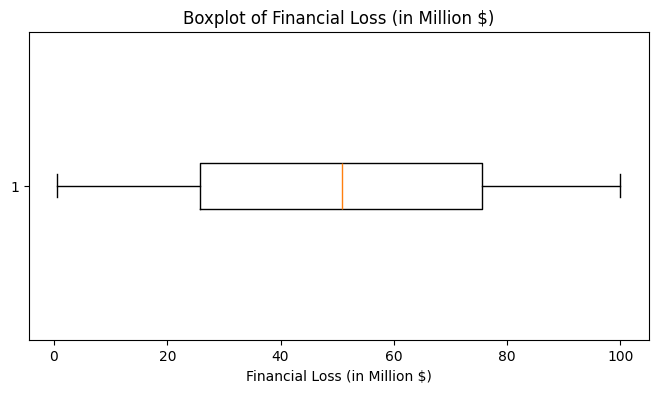

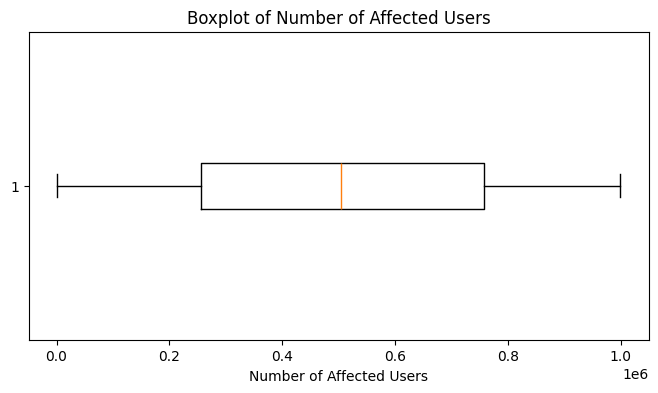

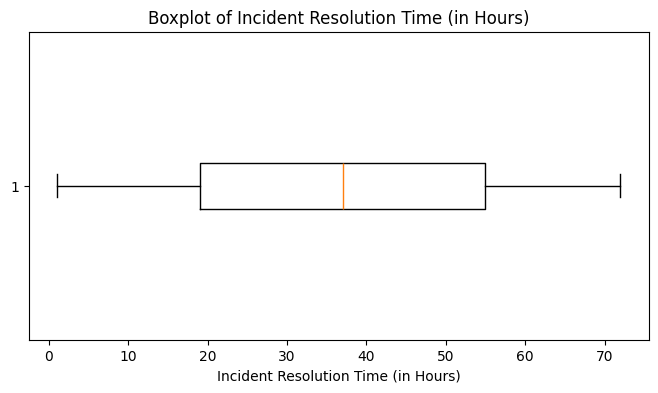

No outliers detected from boxplots.


In [7]:
#Trying to detect outliers for data cleaning
outlier_cols = ['Financial Loss (in Million $)',
                'Number of Affected Users',
                'Incident Resolution Time (in Hours)']

for col in outlier_cols:
    plt.figure(figsize=(8, 4))
    plt.boxplot(df[col].dropna(), vert=False)  # <-- Make it horizontal
    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)  # Use xlabel now (not ylabel)
    plt.show()

print("No outliers detected from boxplots.")

In [8]:
#Creating new column for 'loss per user'
df['Loss per User'] = (df['Financial Loss (in Million $)'] * 1_000_000) / df['Number of Affected Users']
df['Loss per User'] = df.apply(lambda x: (x['Financial Loss (in Million $)'] * 1_000_000) / x['Number of Affected Users'] if x['Number of Affected Users'] != 0 else None, axis=1)


def group_year(year):
    year = int(year)  # Make sure it's a number
    if 2015 <= year <= 2019:
        return '2015-2019'
    elif 2020 <= year <= 2024:
        return '2020-2024'
    else:
        return 'Other'

df['Time Period'] = df['Year'].apply(group_year)


### Exploratory Data Analysis

In [9]:
df.info()

#Calling for summary statistics.
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 12 columns):
 #   Column                               Non-Null Count  Dtype   
---  ------                               --------------  -----   
 0   Country                              3000 non-null   object  
 1   Year                                 3000 non-null   category
 2   Attack Type                          3000 non-null   object  
 3   Target Industry                      3000 non-null   object  
 4   Financial Loss (in Million $)        3000 non-null   float64 
 5   Number of Affected Users             3000 non-null   int64   
 6   Attack Source                        3000 non-null   object  
 7   Security Vulnerability Type          3000 non-null   object  
 8   Defense Mechanism Used               3000 non-null   object  
 9   Incident Resolution Time (in Hours)  3000 non-null   int64   
 10  Loss per User                        3000 non-null   float64 
 11  Time Period      

,Financial Loss (in Million $),Number of Affected Users,Incident Resolution Time (in Hours),Loss per User
count,3000.000000,3000.000000,3000.000000,3000.000000
mean,50.492970,504684.136333,36.476000,515.184504
std,28.791415,289944.084972,20.570768,4325.834901
min,0.500000,424.000000,1.000000,0.620994
25%,25.757500,255805.250000,19.000000,49.862220
50%,50.795000,504513.000000,37.000000,100.312440
75%,75.630000,758088.500000,55.000000,202.896344
max,99.990000,999635.000000,72.000000,141058.020478


In [10]:
# Number of unique values for 'Attack Type'
print("Unique Attack Types:", df['Attack Type'].nunique())
print(df['Attack Type'].value_counts(), "\n")

# Number of unique values for 'Target Industry'
print("Unique Target Industries:", df['Target Industry'].nunique())
print(df['Target Industry'].value_counts(), "\n")



Unique Attack Types: 6
Attack Type
Ddos                 531
Phishing             529
Sql Injection        503
Ransomware           493
Malware              485
Man-In-The-Middle    459
Name: count, dtype: int64 

Unique Target Industries: 7
Target Industry
IT                    478
Banking               445
Healthcare            429
Retail                423
Education             419
Government            403
Telecommunications    403
Name: count, dtype: int64 



In [11]:
#Computing descriptive statistics for numeric columns.
numeric_cols = ['Financial Loss (in Million $)', 'Number of Affected Users', 'Incident Resolution Time (in Hours)', 'Loss per User']
df[numeric_cols].describe()



,Financial Loss (in Million $),Number of Affected Users,Incident Resolution Time (in Hours),Loss per User
count,3000.000000,3000.000000,3000.000000,3000.000000
mean,50.492970,504684.136333,36.476000,515.184504
std,28.791415,289944.084972,20.570768,4325.834901
min,0.500000,424.000000,1.000000,0.620994
25%,25.757500,255805.250000,19.000000,49.862220
50%,50.795000,504513.000000,37.000000,100.312440
75%,75.630000,758088.500000,55.000000,202.896344
max,99.990000,999635.000000,72.000000,141058.020478


In [12]:
#The most common attack types
print(df['Attack Type'].value_counts().head(5))

#The most targeted industries
print(df['Target Industry'].value_counts().head(5))


Attack Type
Ddos             531
Phishing         529
Sql Injection    503
Ransomware       493
Malware          485
Name: count, dtype: int64
Target Industry
IT            478
Banking       445
Healthcare    429
Retail        423
Education     419
Name: count, dtype: int64


### Data Visualization and Interpretation

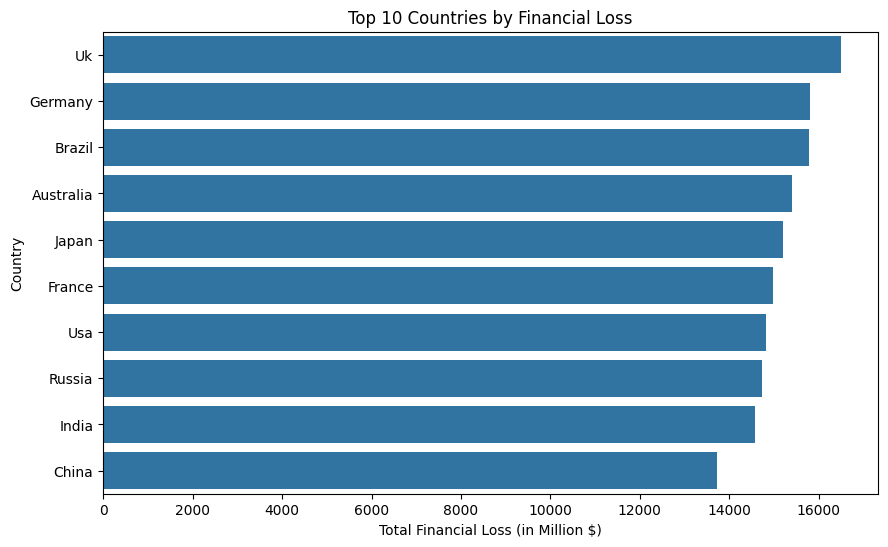

In [13]:
top_countries = df.groupby('Country')['Financial Loss (in Million $)'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_countries.values, y=top_countries.index)
plt.title('Top 10 Countries by Financial Loss')
plt.xlabel('Total Financial Loss (in Million $)')
plt.ylabel('Country')
plt.show()

The United Kingdom, Germany and Brazil are the countries with the most financial loss. Cyberattacks caused major financial losses not only in Europe but also in emerging economies like Brazil, showing the global nature of cybersecurity risks.

<ipython-input-14-a02ded6e753f>:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  year_attack = df.pivot_table(index='Attack Type', columns='Year', aggfunc='size', fill_value=0)


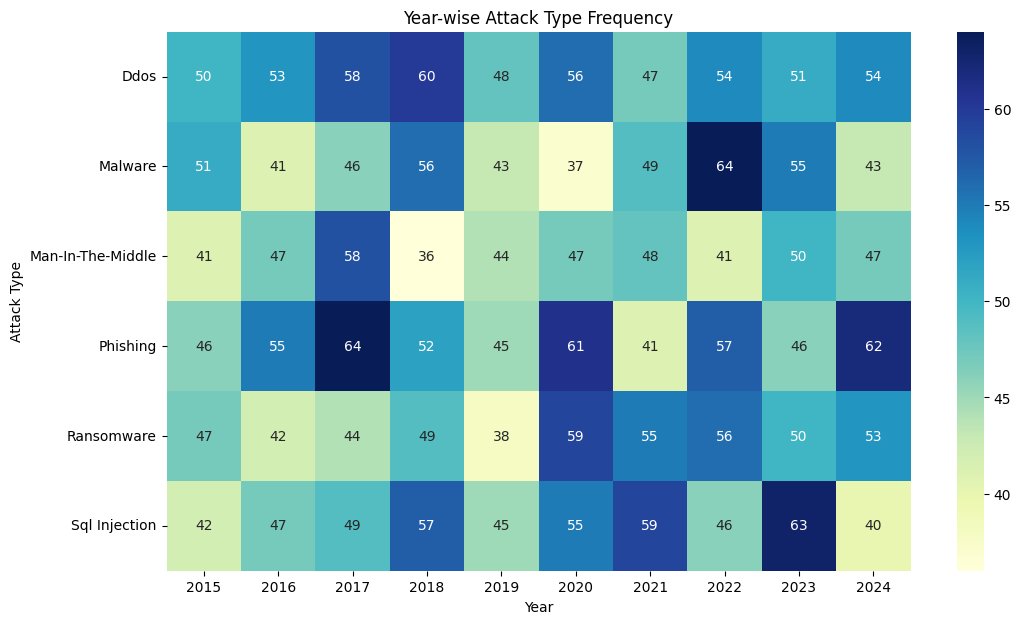

In [14]:
year_attack = df.pivot_table(index='Attack Type', columns='Year', aggfunc='size', fill_value=0)

plt.figure(figsize=(12,7))
sns.heatmap(year_attack, annot=True, fmt="d", cmap="YlGnBu")
plt.title('Year-wise Attack Type Frequency')
plt.xlabel('Year')
plt.ylabel('Attack Type')
plt.show()

Phishing remained the most frequent attack type every year, but ransomware incidents rose sharply after 2019, showing how cyberattack trends evolved over time.


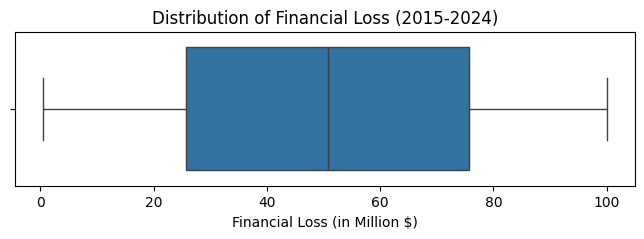

In [15]:
# Boxplot of Financial Loss
plt.figure(figsize=(8,2))
sns.boxplot(x=df['Financial Loss (in Million $)'])
plt.title('Distribution of Financial Loss (2015-2024)')
plt.xlabel('Financial Loss (in Million $)')
plt.show()

There are no extreme financial loss outliers observed; losses are mainly contained within a moderate range.



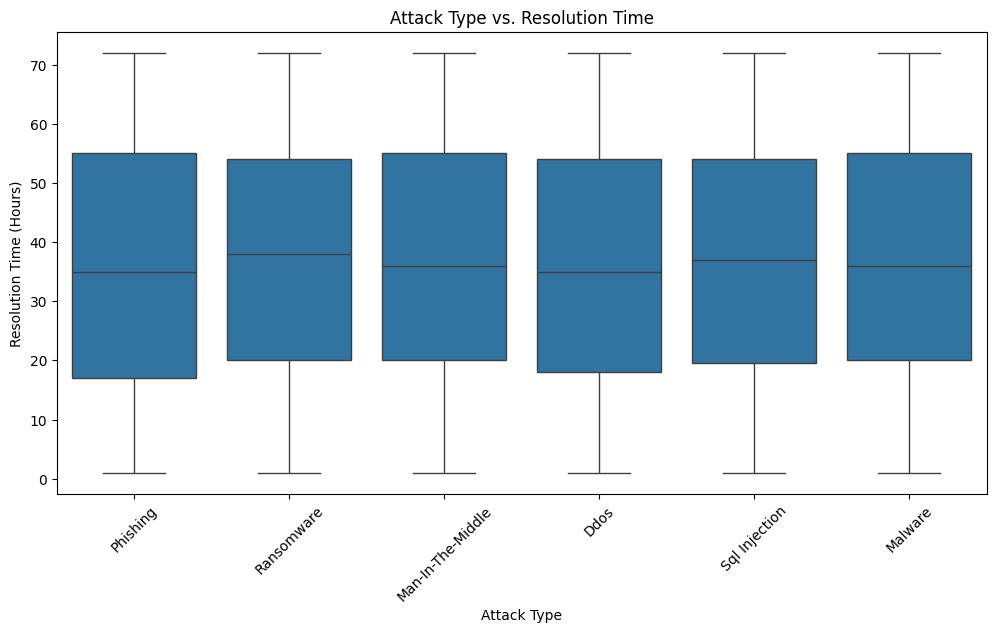

In [16]:
plt.figure(figsize=(12,6))
sns.boxplot(x='Attack Type', y='Incident Resolution Time (in Hours)', data=df)
plt.title('Attack Type vs. Resolution Time')
plt.xlabel('Attack Type')
plt.ylabel('Resolution Time (Hours)')
plt.xticks(rotation=45)
plt.show()

The boxplot shows that across different attack types, the median resolution times are very similar, with most falling within a close range. The interquartile ranges are also fairly consistent, suggesting that, regardless of attack type, most incidents are resolved in a comparable amount of time.



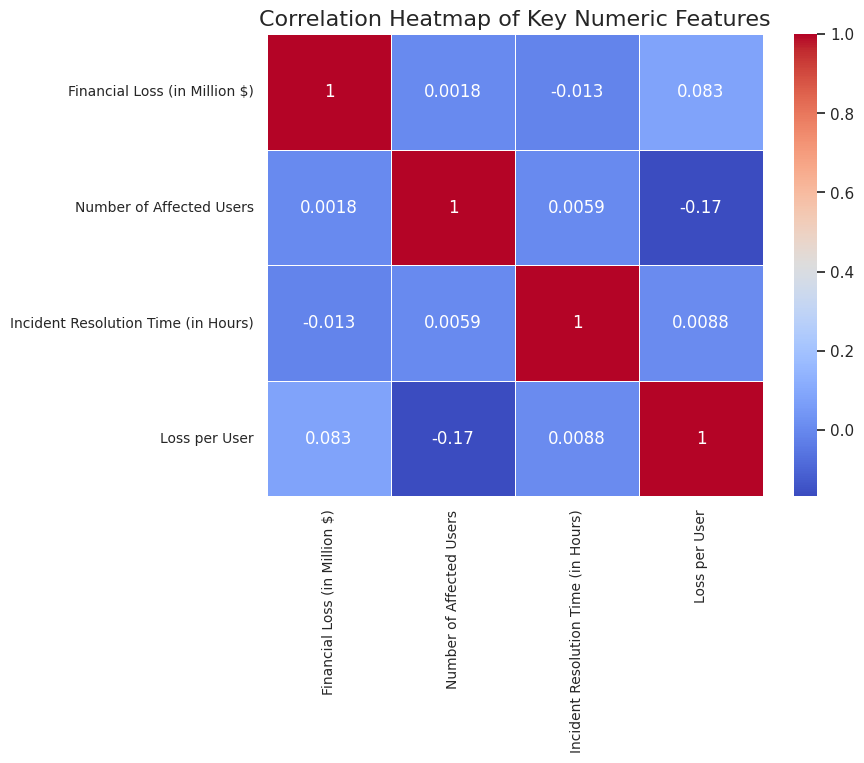

In [17]:
plt.figure(figsize=(8,6))
sns.set_theme(style="white")
corr = df[['Financial Loss (in Million $)', 'Number of Affected Users', 'Incident Resolution Time (in Hours)', 'Loss per User']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Key Numeric Features', fontsize=16)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.show()


Financial Loss shows a positive correlation with the number of affected users, indicating that larger breaches tend to be more costly. However, resolution time reflects a weak correlation with financial loss.

### Insights and Generalizations

**Which countries and industries suffered the most?**

Uk, Brazil and Germany had the most financial loss. The UK, Brazil and India had the most counts of attacks (321, 310, 308 respectively). In addition, the IT, Banking and Healthcare industries were hit the hardest with the most counts of cyber attacks.

In [18]:
industry_counts = df['Target Industry'].value_counts()
print(industry_counts.head(10))


Target Industry
IT                    478
Banking               445
Healthcare            429
Retail                423
Education             419
Government            403
Telecommunications    403
Name: count, dtype: int64


**Which types of attacks caused the highest losses or affected the most users?**

Ddos, phising, sql injection, ransomware, and malware caused the highest losses and were within close range in terms of financial impact. They also affected the most users in that respective order.

In [19]:
loss_by_attack = df.groupby('Attack Type')['Financial Loss (in Million $)'].sum().sort_values(ascending=False)
print(loss_by_attack.head(5))

users_by_attack = df.groupby('Attack Type')['Number of Affected Users'].sum().sort_values(ascending=False)
print(users_by_attack.head(5))


Attack Type
Ddos             27630.92
Phishing         26693.29
Sql Injection    25156.56
Ransomware       24479.32
Malware          23967.95
Name: Financial Loss (in Million $), dtype: float64
Attack Type
Ddos             265201265
Sql Injection    257772326
Phishing         257717975
Ransomware       247892907
Malware          246758413
Name: Number of Affected Users, dtype: int64


**Are some defense mechanisms associated with faster resolution?**

According to the dataset, the five most commonly used defense mechanisms were firewalls, antivirus software, encryption methods, AI-based detection systems, and VPNs.
When examining the average incident resolution times associated with each, all fell within the general median range observed across all attack types.
This suggests that while different defense strategies are employed, they do not appear to significantly speed up or slow down resolution time compared to the overall average response pattern.

In [20]:
defense_resolution = df.groupby('Defense Mechanism Used')['Incident Resolution Time (in Hours)'].mean().sort_values()
print(defense_resolution)


Defense Mechanism Used
Firewall              35.714530
Antivirus             36.573248
Encryption            36.589527
AI-based Detection    36.612350
VPN                   36.864379
Name: Incident Resolution Time (in Hours), dtype: float64


**Any surprising patterns or outliers?**

One surprising pattern observed was that the countries experiencing the highest financial losses were the United Kingdom, Germany, and Brazil, rather than larger economies such as the United States or China.


**Are there any limitations of the dataset?**

Overall, while the dataset provided helpful information about cybersecurity attacks, it does not capture every detail. Some incidents may not have been reported at all, and the information that was reported may vary depending on the country or industry. Because of this, the patterns we see are useful, but they might not represent the full picture of all cybersecurity events during this time.



### Additional Research

**1. What were industries had the most financial loss?**


In [21]:
industry_loss = df.groupby('Target Industry')['Financial Loss (in Million $)'].sum().sort_values(ascending=False)
print(industry_loss.head(10))


Target Industry
IT                    24809.83
Banking               22772.39
Government            21205.33
Retail                21119.55
Healthcare            21041.29
Telecommunications    20459.09
Education             20071.43
Name: Financial Loss (in Million $), dtype: float64


**2. How do the data points of the shortest and longest resolution time contrast?**

Comparing the shortest and longest resolution times reveals that simple attacks affecting fewer users are resolved much faster, while complex attacks impacting sensitive sectors and larger populations lead to significantly longer incident management timelines.

In [22]:
print("Shortest Resolution Time Data Points:")

# Find the row with the minimum Incident Resolution Time
shortest_resolution = df.loc[df['Incident Resolution Time (in Hours)'].idxmin()]
shortest_resolution_df = shortest_resolution.to_frame().T
display(shortest_resolution_df)



Shortest Resolution Time Data Points:


,Country,Year,Attack Type,Target Industry,Financial Loss (in Million $),Number of Affected Users,Attack Source,Security Vulnerability Type,Defense Mechanism Used,Incident Resolution Time (in Hours),Loss per User,Time Period
96,Germany,2024,Phishing,Healthcare,84.53,189430,Nation-state,Social Engineering,Firewall,1,446.233437,2020-2024


In [23]:
print("Longest Resolution Time Data Points:")

# Find the row with the maximum Incident Resolution Time
longest_resolution = df.loc[df['Incident Resolution Time (in Hours)'].idxmax()]
longest_resolution_df = longest_resolution.to_frame().T
display(longest_resolution_df)


Longest Resolution Time Data Points:


,Country,Year,Attack Type,Target Industry,Financial Loss (in Million $),Number of Affected Users,Attack Source,Security Vulnerability Type,Defense Mechanism Used,Incident Resolution Time (in Hours),Loss per User,Time Period
143,Germany,2022,Ddos,IT,78.18,987652,Hacker Group,Social Engineering,VPN,72,79.157436,2020-2024


**3. How has the total financial loss from cyberattacks changed over time (2015–2024)?**

The financial losesses spiked after 2019 and plummited before 2019.

<ipython-input-24-5d3c226be52c>:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  yearly_loss = df.groupby('Year')['Financial Loss (in Million $)'].sum()


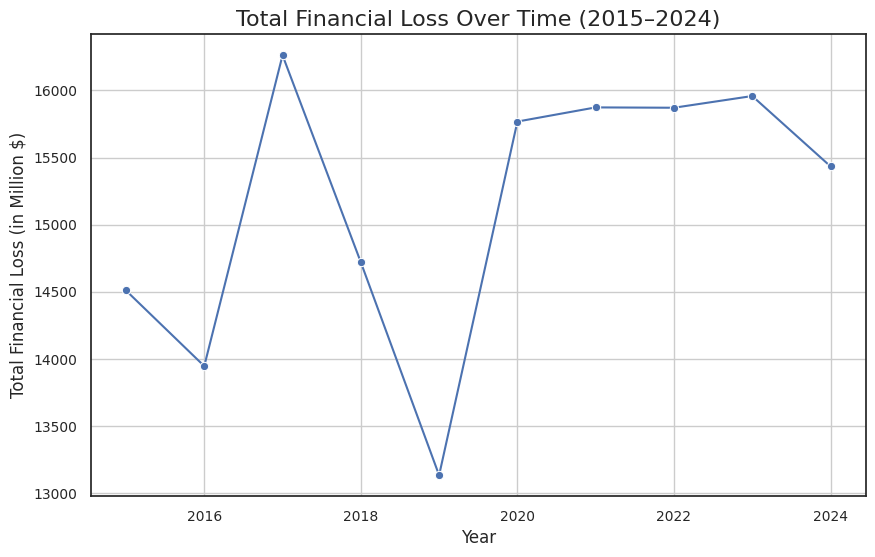

In [24]:
# Grouping financial loss by Year
yearly_loss = df.groupby('Year')['Financial Loss (in Million $)'].sum()

plt.figure(figsize=(10,6))
sns.lineplot(x=yearly_loss.index, y=yearly_loss.values, marker="o")
plt.title('Total Financial Loss Over Time (2015–2024)', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Financial Loss (in Million $)', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(True)
plt.show()